In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:

df = pd.read_csv(r"C:\Users\91739\OneDrive\Desktop\bikewale\Data\bikewale_bikes.csv")
df.shape

(420, 8)

In [3]:
df.head()

,Bike_Name,Rating,Total_Ratings,Engine_CC,Mileage,Power_BHP,Weight_KG,Price
0,EV,TVS iQube,770 Ratings,124.8 cc,35 kmpl,20.2 bhp,129.7 kg,"₹ 1,13,742"
1,EV,Bajaj Chetak,651 Ratings,124.8 cc,35 kmpl,20.2 bhp,195 kg,"₹ 1,10,922"
2,Bajaj Pulsar N160,4.6,1217 Ratings,164.82 cc,51.6 kmpl,15.68 bhp,152 kg,"₹ 1,16,504"
3,TVS Ronin,4.6,1081 Ratings,225.9 cc,42 kmpl,20.1 bhp,160 kg,"₹ 1,28,731"
4,Royal Enfield Hunter 350,4.7,1562 Ratings,349.34 cc,36.2 kmpl,20.2 bhp,181 kg,"₹ 1,37,648"


# Obseravtion:
### Categorical Columns

* Bike_Name
* Brand

### Discrete Numerical Columns

* Total_Ratings

### Continuous Numerical Columns

* Price
* Rating
* Engine_CC
* Mileage
* Power_BHP
* Weight_KG


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Bike_Name      420 non-null    object
 1   Rating         420 non-null    object
 2   Total_Ratings  420 non-null    object
 3   Engine_CC      420 non-null    object
 4   Mileage        420 non-null    object
 5   Power_BHP      420 non-null    object
 6   Weight_KG      420 non-null    object
 7   Price          420 non-null    object
dtypes: object(8)
memory usage: 26.4+ KB


In [5]:
df.columns

Index(['Bike_Name', 'Rating', 'Total_Ratings', 'Engine_CC', 'Mileage',
       'Power_BHP', 'Weight_KG', 'Price'],
      dtype='object')

In [6]:
df.isnull().sum()/len(df)*100

Bike_Name        0.0
Rating           0.0
Total_Ratings    0.0
Engine_CC        0.0
Mileage          0.0
Power_BHP        0.0
Weight_KG        0.0
Price            0.0
dtype: float64

In [7]:
# Removing null values:
df["Engine_CC"] = df["Engine_CC"].fillna(df["Engine_CC"].mode()[0])
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].mode()[0])
df["Power_BHP"] = df["Power_BHP"].fillna(df["Power_BHP"].mode()[0])
df["Weight_KG"] = df["Weight_KG"].fillna(df["Weight_KG"].mode()[0])

In [8]:
df.describe()

,Bike_Name,Rating,Total_Ratings,Engine_CC,Mileage,Power_BHP,Weight_KG,Price
count,420,420,420,420,420,420,420,420
unique,29,9,30,21,21,22,24,30
top,EV,4.6,770 Ratings,124.8 cc,35 kmpl,20.2 bhp,195 kg,"₹ 1,13,742"
freq,28,112,14,70,70,84,56,14


### Key Observations

1. The dataset contains **420 bike records** with **29 unique bike models**.
2. The most common bike rating is **4.6**, indicating generally positive customer reviews.
3. The most frequently occurring engine capacity is **124.8 cc**, showing the dominance of commuter bikes.
4. The most common mileage is **35 kmpl**, suggesting many bikes focus on fuel efficiency.
5. Missing values are present in **Engine_CC, Mileage, Power_BHP, and Weight_KG**, mainly due to EV bikes having different specifications.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Bike_Name      420 non-null    object
 1   Rating         420 non-null    object
 2   Total_Ratings  420 non-null    object
 3   Engine_CC      420 non-null    object
 4   Mileage        420 non-null    object
 5   Power_BHP      420 non-null    object
 6   Weight_KG      420 non-null    object
 7   Price          420 non-null    object
dtypes: object(8)
memory usage: 26.4+ KB


In [10]:
print(len(df))

420


### Non visual analysis:


In [11]:
"""Data Cleaning Comments
Checked the dataset structure and data types.
Identified missing values in the dataset.
Filled missing values using appropriate methods.
Removed unnecessary symbols and units from numerical columns.
Converted Rating column to numeric datatype.
Converted Total_Ratings column to numeric datatype.
Converted Engine_CC column to numeric datatype.
Converted Mileage column to numeric datatype.
Converted Power_BHP column to numeric datatype.
Converted Weight_KG column to numeric datatype.
Converted Price column to numeric datatype.
Verified data types after conversion.
Checked for duplicate records in the dataset.
Validated data consistency and accuracy.
Prepared the dataset for Exploratory Data Analysis (EDA)."""

'Data Cleaning Comments\nChecked the dataset structure and data types.\nIdentified missing values in the dataset.\nFilled missing values using appropriate methods.\nRemoved unnecessary symbols and units from numerical columns.\nConverted Rating column to numeric datatype.\nConverted Total_Ratings column to numeric datatype.\nConverted Engine_CC column to numeric datatype.\nConverted Mileage column to numeric datatype.\nConverted Power_BHP column to numeric datatype.\nConverted Weight_KG column to numeric datatype.\nConverted Price column to numeric datatype.\nVerified data types after conversion.\nChecked for duplicate records in the dataset.\nValidated data consistency and accuracy.\nPrepared the dataset for Exploratory Data Analysis (EDA).'

In [12]:
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"])

In [13]:

# Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Engine_CC
df["Engine_CC"] = df["Engine_CC"].str.replace(" cc", "", regex=False)
df["Engine_CC"] = pd.to_numeric(df["Engine_CC"], errors="coerce")

# Mileage
df["Mileage"] = df["Mileage"].str.replace(" kmpl", "", regex=False)
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

# Power_BHP
df["Power_BHP"] = df["Power_BHP"].str.replace(" bhp", "", regex=False)
df["Power_BHP"] = pd.to_numeric(df["Power_BHP"], errors="coerce")

# Weight_KG
df["Weight_KG"] = df["Weight_KG"].str.replace(" kg", "", regex=False)
df["Weight_KG"] = pd.to_numeric(df["Weight_KG"], errors="coerce")

In [14]:
df.loc[df["Price"].idxmax()]

Bike_Name        Royal Enfield Continental GT 650
Rating                                        4.8
Total_Ratings                        1498 Ratings
Engine_CC                                   648.0
Mileage                                      25.0
Power_BHP                                    47.0
Weight_KG                                   211.0
Price                                      352687
Name: 12, dtype: object

In [15]:
df.loc[df["Price"].idxmin()]

Bike_Name        Honda Activa
Rating                    4.4
Total_Ratings    4124 Ratings
Engine_CC              109.51
Mileage                  47.0
Power_BHP                7.88
Weight_KG               105.0
Price                   78166
Name: 17, dtype: object



* **Royal Enfield Continental GT 650** is the highest-priced bike in the dataset at **₹3,52,687**.
* **Honda Activa** is the lowest-priced bike in the dataset at **₹78,166**.


In [16]:
df.groupby("Mileage")["Price"].mean().sort_values(ascending=False)

Mileage
25.0    352687.0
29.0    305723.0
28.0    241745.0
31.0    220871.0
32.0    198646.0
30.0    195313.0
35.0    161994.0
46.0    161469.5
44.0    138823.0
36.2    137648.0
36.0    136755.0
42.0    128731.0
51.6    116504.0
61.0    109971.0
47.0    108361.0
46.9     94048.0
66.0     92843.0
63.0     89406.0
48.5     88438.0
56.7     85344.0
50.0     83772.5
Name: Price, dtype: float64

- High cost bikes giving low Mileage.
- Low price bikes giving high Mileage compared to costly bikes.
- so i will suggest low cost bikes for Money saving.

In [17]:
df.groupby("Engine_CC")["Mileage"].mean()

Engine_CC
109.51    47.000000
123.94    63.000000
124.40    50.000000
124.45    46.900000
124.70    66.000000
124.80    45.040000
155.00    46.333333
159.70    61.000000
164.82    51.600000
199.50    36.000000
225.90    42.000000
249.00    44.000000
249.07    31.000000
334.00    30.000000
349.00    32.666667
349.34    34.100000
440.00    35.000000
451.65    29.000000
452.00    28.000000
648.00    25.000000
Name: Mileage, dtype: float64

- Bikes with smaller engine capacities (120–160 cc) provide higher mileage, ranging from 46 to 66 kmpl.

In [18]:
df.groupby("Engine_CC")["Weight_KG"].mean()

Engine_CC
109.51    105.000000
123.94    117.000000
124.40    140.000000
124.45    144.000000
124.70    136.000000
124.80    134.340000
155.00    139.666667
159.70    138.000000
164.82    152.000000
199.50    158.000000
225.90    160.000000
249.00    162.000000
249.07    162.800000
334.00    185.000000
349.00    189.666667
349.34    186.000000
440.00    190.500000
451.65    195.000000
452.00    185.000000
648.00    211.000000
Name: Weight_KG, dtype: float64

- Low-capacity bikes (109–125 cc) typically weigh between 105–144 kg, while high-capacity bikes (440–648 cc) weigh between 185–211 kg. 

In [19]:
pd.pivot_table(df,
               index="Engine_CC",
               values="Price",
               aggfunc="mean")

,Price
Engine_CC,
109.51,78166.000000
123.94,89406.000000
124.40,82420.000000
124.45,94048.000000
124.70,92843.000000
124.80,96714.200000
155.00,162245.666667
159.70,109971.000000
164.82,116504.000000


- As engine capacity increases, the average price of bikes also increases significantly.

In [20]:
pd.pivot_table(df,
               index="Engine_CC",
               values="Power_BHP",
               aggfunc="mean")

,Power_BHP
Engine_CC,
109.51,7.880
123.94,10.720
124.40,11.640
124.45,11.800
124.70,11.400
124.80,13.778
155.00,18.100
159.70,15.820
164.82,15.680


- Bikes with larger engines deliver substantially higher performance compared to commuter bikes.

In [21]:
df.groupby("Engine_CC")[["Power_BHP","Price"]].mean()

,Power_BHP,Price
Engine_CC,,
109.51,7.880,78166.000000
123.94,10.720,89406.000000
124.40,11.640,82420.000000
124.45,11.800,94048.000000
124.70,11.400,92843.000000
124.80,13.778,96714.200000
155.00,18.100,162245.666667
159.70,15.820,109971.000000
164.82,15.680,116504.000000


- Bikes with smaller engines provide higher mileage and lower prices, making them suitable for daily commuting.
- High-capacity bikes offer lower mileage but command higher prices due to their superior performance and features.

In [22]:
df.groupby("Engine_CC")[["Mileage","Price"]].mean()

,Mileage,Price
Engine_CC,,
109.51,47.000000,78166.000000
123.94,63.000000,89406.000000
124.40,50.000000,82420.000000
124.45,46.900000,94048.000000
124.70,66.000000,92843.000000
124.80,45.040000,96714.200000
155.00,46.333333,162245.666667
159.70,61.000000,109971.000000
164.82,51.600000,116504.000000


- **Higher engine capacity bikes tend to be more expensive and offer lower mileage, while lower engine capacity bikes are more fuel-efficient and affordable.**


In [23]:
df.corr(numeric_only=True)

,Rating,Engine_CC,Mileage,Power_BHP,Weight_KG,Price
Rating,1.000000,0.259920,-0.131129,0.148014,0.324145,0.258030
Engine_CC,0.259920,1.000000,-0.744208,0.860516,0.835818,0.909762
Mileage,-0.131129,-0.744208,1.000000,-0.796716,-0.762428,-0.759927
Power_BHP,0.148014,0.860516,-0.796716,1.000000,0.785265,0.935669
Weight_KG,0.324145,0.835818,-0.762428,0.785265,1.000000,0.772619
Price,0.258030,0.909762,-0.759927,0.935669,0.772619,1.000000


- Higher engine capacity increases bike price, power, and weight, whereas mileage tends to decrease.

### Visual analysis:

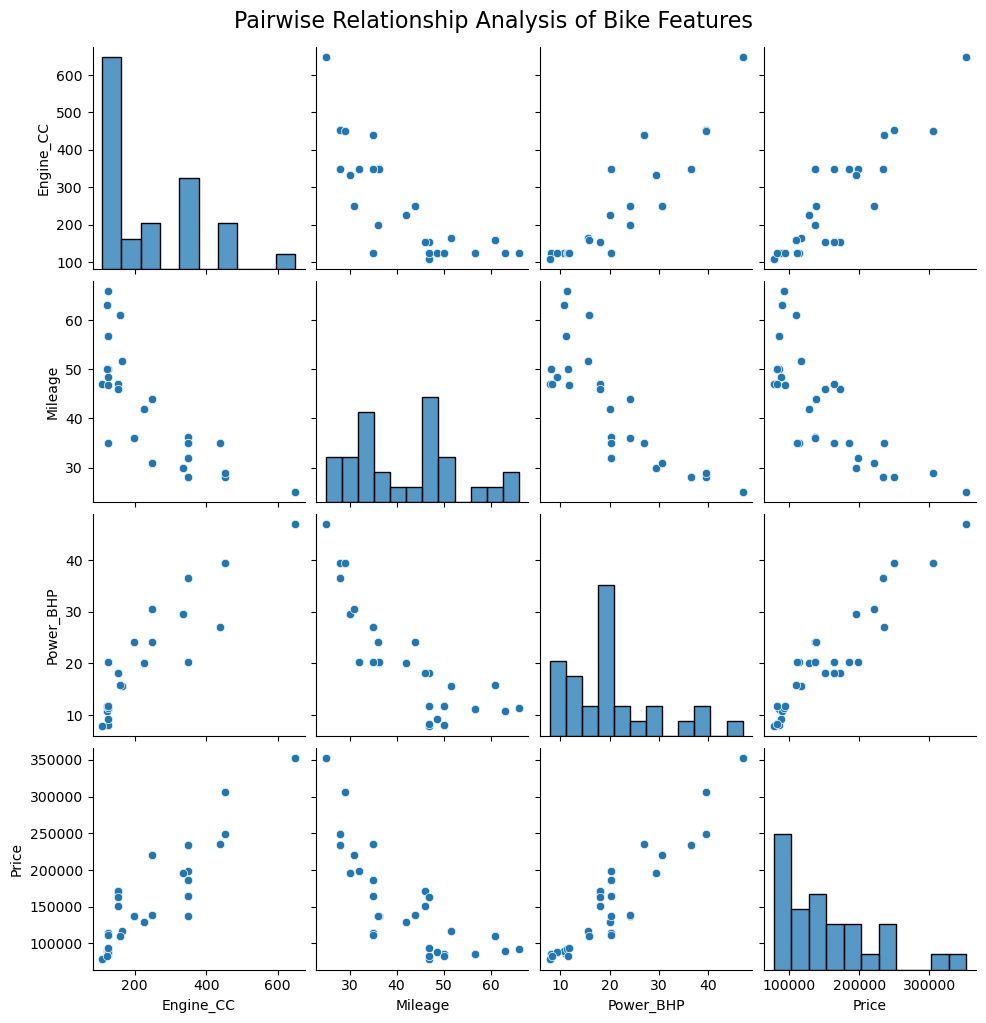

In [24]:
pair_plot = sns.pairplot(
    df[["Engine_CC", "Mileage", "Power_BHP", "Price"]],
    diag_kind="hist"
)

pair_plot.fig.suptitle(
    "Pairwise Relationship Analysis of Bike Features",
    fontsize=16,
    y=1.02
)

plt.show()

- The pair plot shows that bikes with higher engine capacity generally have higher power and price, while mileage tends to decrease as engine capacity increases.

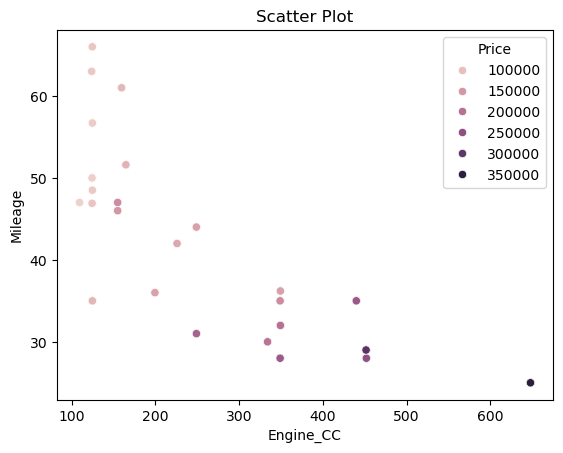

In [25]:
sns.scatterplot(
    data=df,
    x="Engine_CC",
    y="Mileage",
    hue="Price"
)
plt.title("Scatter Plot")
plt.show()

**Observation:** The scatter plot shows a clear negative relationship between **Engine_CC** and **Mileage**—as engine capacity increases, mileage decreases. Additionally, bikes with higher engine capacities tend to belong to higher price segments, as indicated by the darker-colored points.


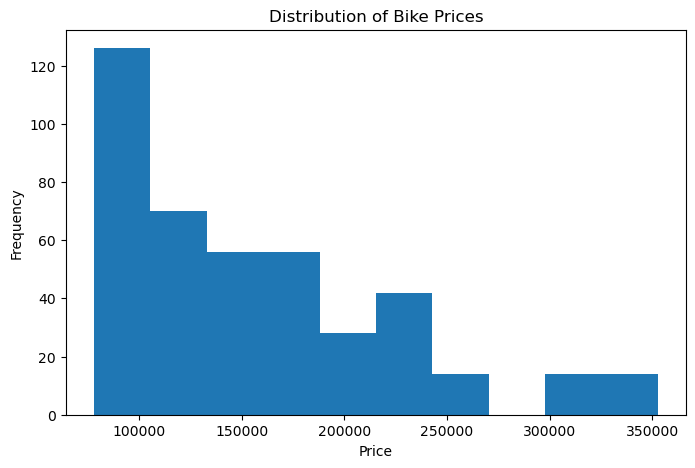

In [26]:
# Histo plot:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10)
plt.title("Distribution of Bike Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

-  Most bikes are priced between ₹80,000 and ₹2,00,000, while only a small number of bikes are priced above ₹3,00,000, indicating that the dataset is dominated by affordable and mid-range bikes with a few premium models.

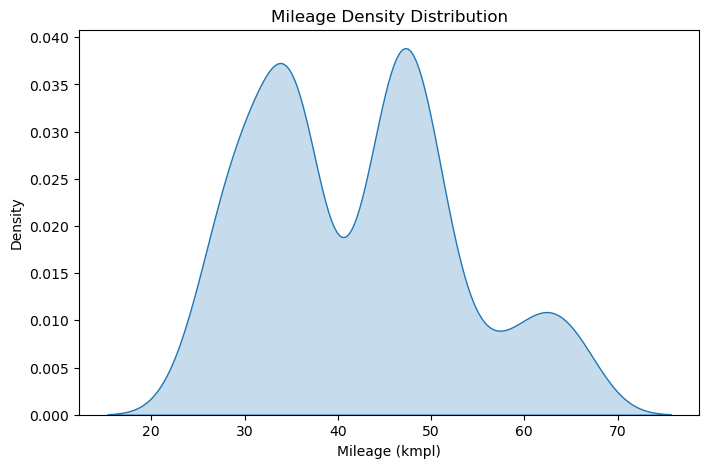

In [27]:
# Kde plot:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Mileage"], fill=True)
plt.title("Mileage Density Distribution")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Density")
plt.show()

- The KDE plot indicates that most bikes have mileage between 30 and 50 kmpl, with peak densities around 35 kmpl and 47 kmpl, suggesting that the dataset is dominated by moderately fuel-efficient bikes.

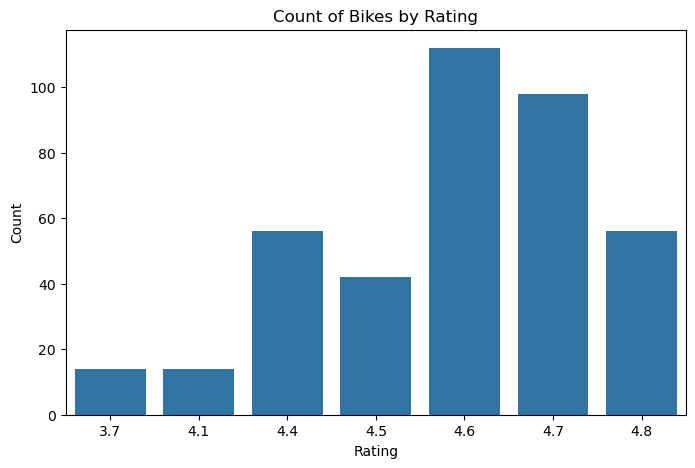

In [28]:
# count plot
plt.figure(figsize=(8,5))
sns.countplot(x="Rating", data=df)
plt.title("Count of Bikes by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

- The majority of bikes have ratings between 4.6 and 4.7, indicating high customer satisfaction, while very few bikes have ratings below 4.2, suggesting that most bike models are well-received by users.

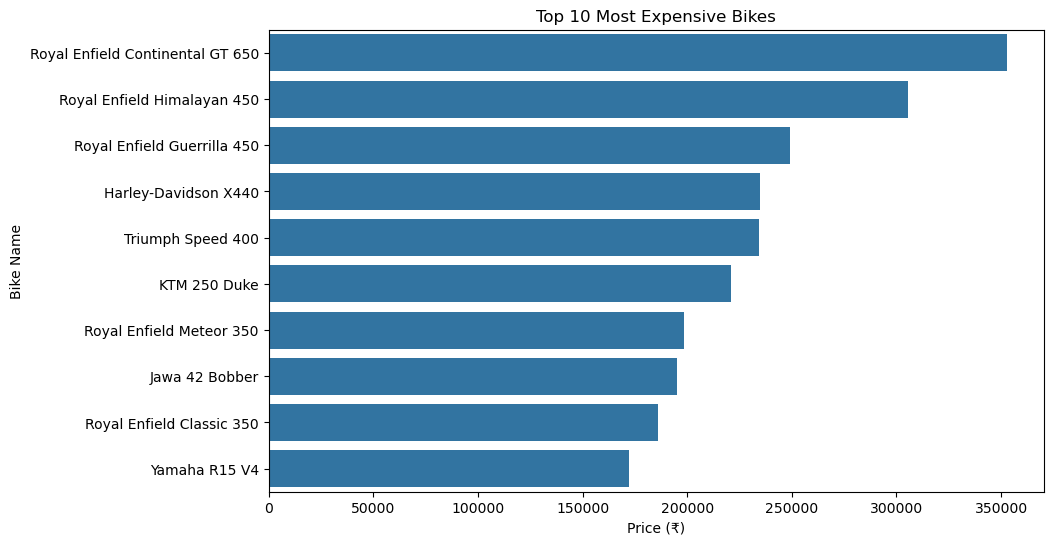

In [29]:
# Top 10 expensive bokes:
top10 = df.groupby("Bike_Name")["Price"].max().reset_index()
top10 = top10.sort_values("Price", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Price", y="Bike_Name")
plt.title("Top 10 Most Expensive Bikes")
plt.xlabel("Price (₹)")
plt.ylabel("Bike Name")
plt.show()

- Royal Enfield Continental GT 650 is the costliest bike in the dataset.
- Premium bikes from Royal Enfield, Harley-Davidson, KTM, and Triumph occupy the top price positions.
- Higher-performance bikes generally command significantly higher prices than commuter bikes.

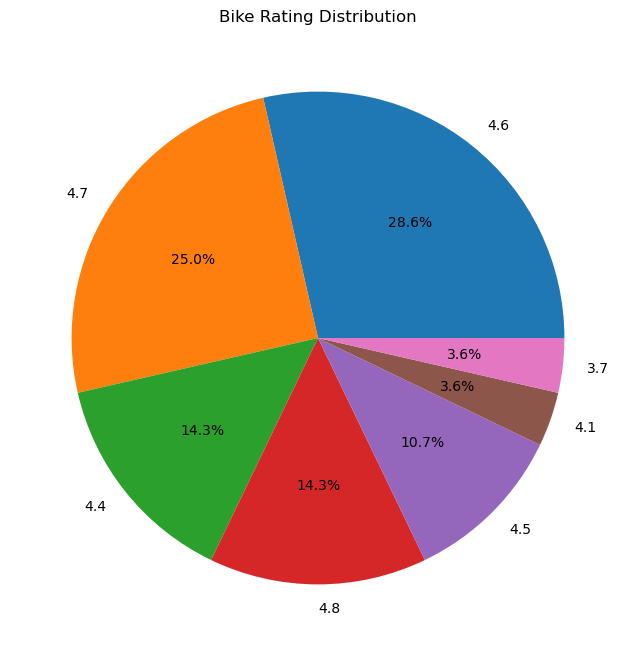

In [30]:
# pie chart:

rating_count = df["Rating"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    rating_count,
    labels=rating_count.index,
    autopct="%1.1f%%"
)
plt.title("Bike Rating Distribution")
plt.show()

- Low ratings such as 3.7 and 4.1 account for only a small portion of the dataset, suggesting that customer satisfaction is generally high across most bike models.

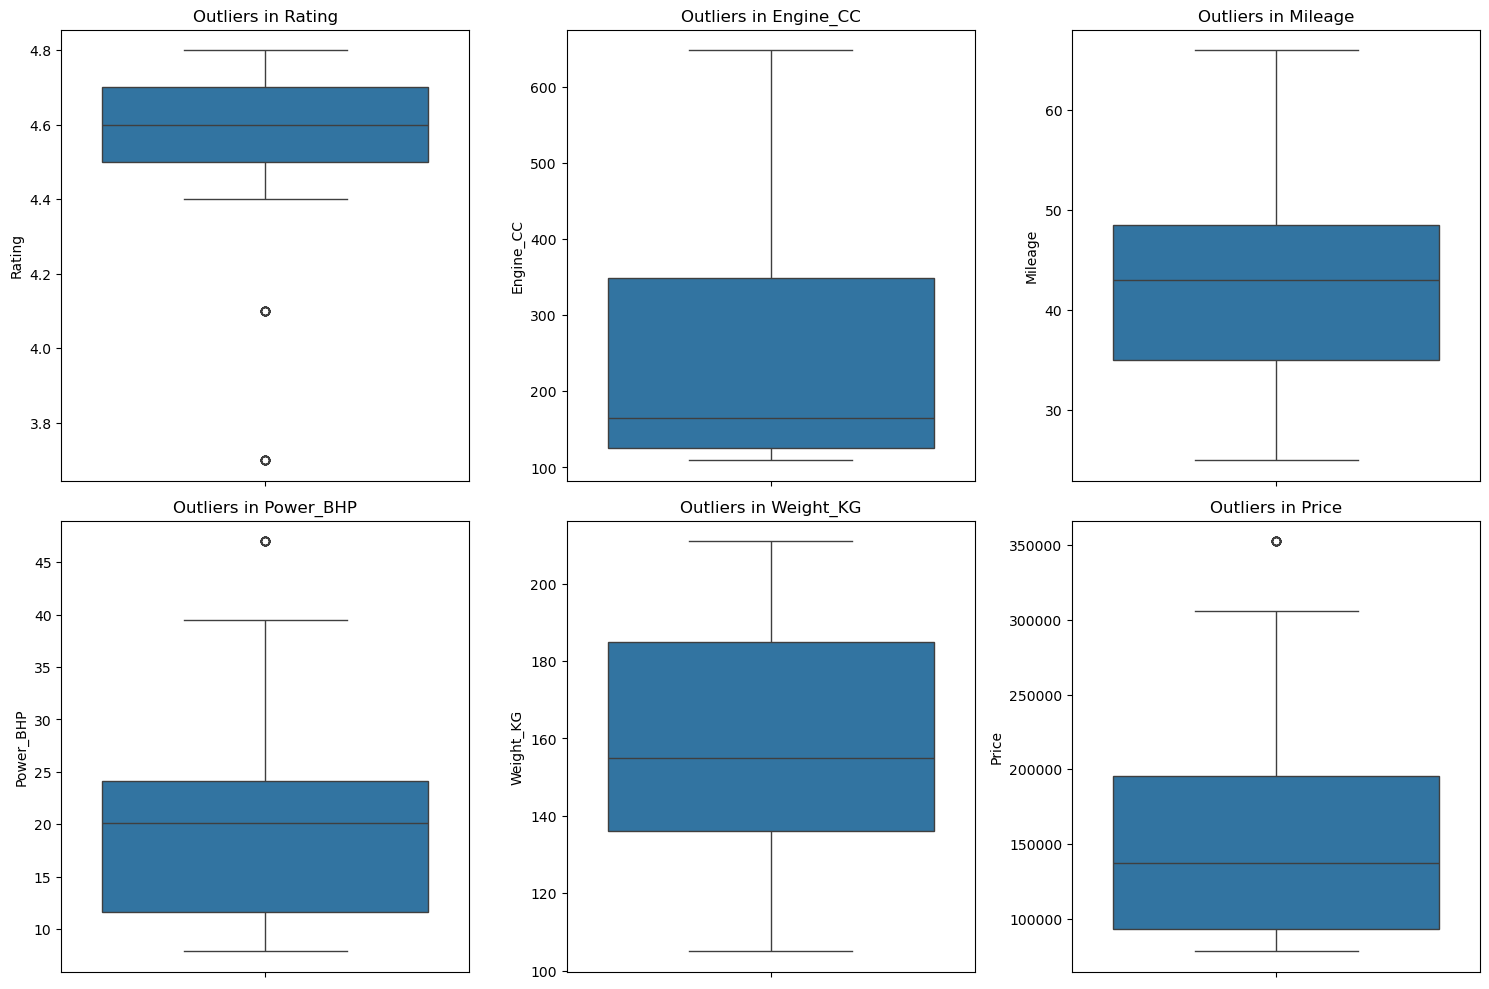

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Outliers in {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* **Rating:** Most bikes have consistently high ratings (4.4–4.8), with a few lower-rated bikes appearing as outliers.
* **Engine_CC:** Engine capacity varies widely, indicating the presence of both commuter and high-performance motorcycles.
* **Mileage:** Mileage values are fairly distributed with no significant outliers, showing consistent fuel efficiency ranges.
* **Power_BHP:** A few high-power bikes stand out as outliers, representing performance-oriented models.
* **Weight_KG:** Bike weights are moderately spread and do not exhibit any major outliers.
* **Price:** A small number of premium bikes have exceptionally high prices, making them clear outliers in the dataset.


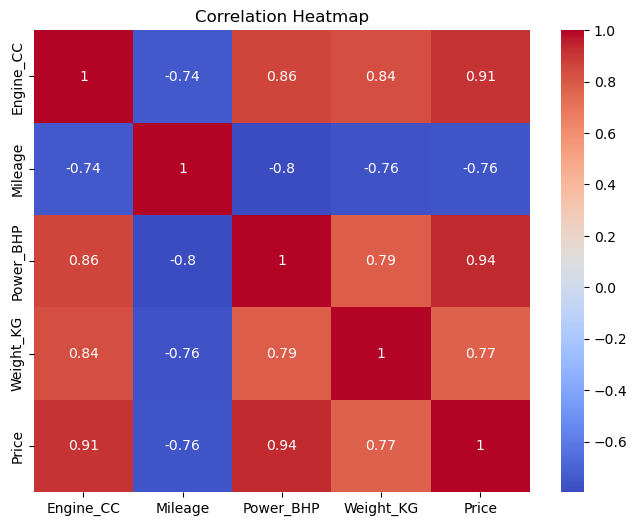

In [32]:
# corelation heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["Engine_CC","Mileage","Power_BHP","Weight_KG","Price"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

1. **Bikes with a rating of 4.6 constitute the largest share (28.6%) of the dataset, making it the most common rating category.**

2. **Ratings of 4.6 and 4.7 together account for more than 50% of all bikes, indicating strong overall customer satisfaction.**

3. **Higher ratings (4.4 to 4.8) dominate the dataset, suggesting that most bike models receive positive user reviews.**

4. **Lower ratings such as 3.7 and 4.1 represent only a small portion of the dataset, showing that very few bikes are poorly rated by customers.**


## Final Insights:

1. Most bikes have ratings between **4.6 and 4.7**, indicating high customer satisfaction.

2. Engine capacity has a strong impact on **price, power, and mileage**.

3. Higher engine capacity bikes offer more power but lower fuel efficiency.

4. Most bikes belong to the **affordable and mid-range price segment**.

5. Premium bikes command higher prices due to superior performance and features.

---

## Business Recommendations:

1. Focus on producing bikes that balance **performance and fuel efficiency**.

2. Increase offerings in the **commuter segment**, as demand is highest for affordable bikes.

3. Strengthen premium product positioning through advanced features and branding.

4. Continuously monitor customer ratings to improve product quality and satisfaction.

5. Develop targeted marketing strategies for commuter and premium bike segments.

---

## Conclusion:

- The analysis shows that **engine capacity is the primary factor influencing bike price, power, weight, and mileage**.
- While commuter bikes emphasize affordability and fuel efficiency, premium bikes focus on performance and advanced features.
These insights can help manufacturers improve product development, pricing strategies, and market positioning.
